# Wind → Wind-farm · M0 input data · source 02 — SPC + Storm Events tornado & convective-wind record

**Peril:** Wind (tornado + strong/straight-line) · **Layer:** M0 (raw evidence) · *method-neutral — understanding, not the model.*

This is the **second** M0 notebook, and it meets the **other** of wind's two data shapes. Notebook
[`01_asce_hazard`](01_asce_hazard.ipynb) met a **pre-integrated surface** (ASCE — read a return-period curve, no
fit). This one meets a **record of observed events** — the *hail analog*, where frequency and severity are
**extracted and fit** from a catalogue. The tornado sub-peril lives here: it has **no public stochastic catalog**
and **no design surface that covers its violent tail**, so its λ and severity *must* come from this record.

| | **ASCE RP surface** ([`01`](01_asce_hazard.ipynb) — strong wind) | **SPC / Storm Events record** *(this notebook — tornado)* |
|---|---|---|
| shape | pre-integrated return-period field | a **list of observed events** |
| M1 move | profile-assembly (**read** the curve) | **extraction** (fit λ + severity) |
| coupling | site-conditioned (bucket 3) | areal hit-or-miss (bucket 1) |
| the catch | inherit ASCE's assumptions | **population / reporting bias — must be corrected** |

> **The single most important thing this notebook produces is not a number — it is a *caveat*:** the raw counts
> are **population/reporting-biased** (AWN-1), so a count is **not** a hazard rate. §7 *demonstrates* the bias;
> correcting it is M1's job. We do **not** silently filter to 1996+ and call it done (the old repo's omission).

> Plan: [`m0_input_data.md`](../../../docs/plans/convective_wind/m0_input_data.md) · Hazard definition (EF bins, μ):
> [`layer0/01_hazard_definition`](../layer0/01_hazard_definition.ipynb) · Coupling (tornado = areal):
> [`discussion/convective_wind/02`](../../../docs/extra/discussion/convective_wind/02_coupling_buckets_and_wind.md) · Principle:
> [`exploratory_data_notebooks`](../../../docs/principles/notebook_work/exploratory_data_notebooks.md).

## 0 · Intent & scope

**Does:** meet the **tornado track record** (SPC, with path geometry) and the **convective-wind report record**
(SPC severe-wind + NOAA Storm Events); field-dictionary every column; demonstrate the **episode de-duplication**
(one outbreak ≠ many events); **audit the population/reporting bias** (the frequency-critical centerpiece);
extract **per-site tornado path statistics** for the M2 path-aware Minkowski; and emit a clean per-site record +
manifest carrying a **bias-correction TODO flag**.

**Does NOT:** fit a frequency λ, *correct* the bias, choose a primary source, or compute loss — those are M1+.
This notebook **audits** the bias so M1 can correct it. No silent windowing (1996+/2007+) — the full extent is
shown, with the bias made explicit. Sources are public, no auth ([DD-WN-3](../../../docs/plans/convective_wind/decisions.md)).

## Assumptions (this layer)

- **AWN-1** 🔴 — **SPC report / population bias** (frequency-critical): tornado/wind counts are population-biased,
  weak-event detection rose over time, the **F→EF switch (2007)** is a discontinuity, wind reports mix measured
  gusts with damage-only, and EF is **biased low in rural/open land** (both sites rural). **Bias-correct before
  any λ fit** — this notebook demonstrates the bias; M1 corrects it.
- **AWN-7** — EF bins (3-s gust, mph); EF is **damage-inferred** (28 indicators × 8 degrees), not measured.
- **AWN-11** — sources: SPC SVRGIS/WCM tornado tracks (1950+), SPC severe-wind reports (1955+), NOAA Storm Events.
- **AWN-12** — two sites; **AWN-19** — stationary λ in v1 (flag the eastward "Dixie Alley" drift, don't freeze).
- **AWN-21** — tornado coupling = areal hit-or-miss; the path length × width × EF feed the path-aware Minkowski (M2).
- [learning-06](../../../docs/learning_logs/06_collection_region_size_cancels.md) — the collection-region radius
  is a homogeneity/data choice; its *size cancels* in `λ_asset = λ_collection · p_hit`, so it never tunes magnitude.

Full register: [`assumptions.md`](../../../docs/plans/convective_wind/assumptions.md).

## 1 · From-scratch — what *is* this record?

Two record types, both "a list of things that happened," but with different geometry:

- **SPC tornado tracks** — each row is **one tornado**, carrying a **path**: a start point → end point, a
  **length** (miles) and **width** (yards), and an **EF rating**. The *path geometry is unique to tornado* — no
  other wind sub-peril has a line. This is what feeds the **areal hit-or-miss** coupling (a path either clips the
  farm or misses it). Verified: every row is a whole-track record (`sg == 1`), so one row = one tornado.
- **Convective-wind reports** (SPC severe-wind + Storm Events "Thunderstorm/High/Strong Wind") — each row is a
  **point report** of a gust (in **knots**, often *damage-inferred*, not measured). No path. These give
  convective-wind frequency/severity (the SPC record is long; the ASCE surface of `01` is the design spine).

**Row → event mapping.** A tornado row = one event. A wind *report*, though, is one observation — and a single
storm system (one **EPISODE**) can spawn many reports across many counties, so reports must be **de-duplicated to
independent events** (§8) before they mean a frequency. And — the load-bearing point — **a raw count of either is
not a hazard rate**: detection has changed over 75 years (§7). This is the record's defining hazard.

## 2 · The fields + the "a number is meaningless without its base" table

| Field | What it is | Units / reference base | What it is **NOT** | Use |
|---|---|---|---|---|
| `mag` (tornado) | EF/F rating | category **0–5**, `-9` = unknown; **damage-inferred** | not a measured gust; not a continuous speed | tornado severity class |
| `mag` (wind) | estimated peak gust | **knots** (× 1.151 = mph); ~20% are **0** (damage-only) | mostly *not* measured; left-censored at ~50 kt | convective-wind severity |
| `len` / `wid` | tornado path length / width | **miles** / **yards** | not the asset footprint | M2 path-aware Minkowski |
| `mt` / `MAGNITUDE_TYPE` | how the gust was obtained | **EG/MG/MS/ES** = estimated/measured × gust/sustained | — | measured-vs-estimated quality split |
| `slat,slon → elat,elon` | path start → end | degrees (WGS84); end = `0` when unknown | not a single point (it's a line) | path geometry + spatial filter |
| `EPISODE_ID` | storm-system group (Storm Events) | one weather system | **not** one independent event | de-duplication key (§8) |
| `DAMAGE_PROPERTY` / `loss` | NWS $ damage estimate | mixed, inconsistent, **non-PV** basis | **NOT our loss basis** | ⛔ **ignored** (the hail `hail_hlrb`/TIV lesson) |
| count over time | reports per period | **population/detection-biased** | **NOT a hazard rate** | the §7 bias audit only |

> **Frame rule.** A "tornado count" or "wind-report count" is **evidence of detection**, not a frequency, until
> the population/reporting bias is corrected (AWN-1, §7). And `mag` is **two different things** across the two
> records — an EF *class* for tornado, a gust in *knots* for wind — never mix them. EF is *damage-inferred*, so
> it understates severity where there is little to damage (rural — both our sites).

In [1]:
from __future__ import annotations

import gzip
import json
import re
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})

KT_TO_MPH = 1.150779
MI_TO_KM = 1.609344
YD_TO_KM = 0.0009144

EF_BINS_MPH = {0: (65, 85), 1: (86, 110), 2: (111, 135), 3: (136, 165), 4: (166, 200), 5: (201, 253)}
# Old-repo EF-class typical damage-path plan areas (km²), for the M2 cross-check (AWN-21).
OLD_REPO_EF_AREA_KM2 = {0: 0.5, 1: 2.0, 2: 5.0, 3: 9.0, 4: 14.0, 5: 20.0}


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root (AGENTS.md) not found")


ROOT = _repo_root()
DATA_DIR = ROOT / "data" / "convective_wind"
RAW = DATA_DIR / "raw"                       # shared national records (gitignored: data/*/raw/)
RAW.mkdir(parents=True, exist_ok=True)
_UA = {"User-Agent": "infrasure-hazard-modeling/0.1 (M0 research notebook)"}

# Two sites (same as 01). Tornado is areal hit-or-miss, so we collect events in a region AROUND each site.
ASSETS = [
    {"slug": "traverse_wind_ok", "name": "Traverse Wind Energy Center", "role": "proving (high-wind)",
     "state": "OK", "lat": 35.713427, "lon": -98.728532, "capacity_mw": 999.0},
    {"slug": "shepherds_flat_or", "name": "Shepherds Flat", "role": "baseline (low-wind)",
     "state": "OR", "lat": 45.653389, "lon": -120.036724, "capacity_mw": 845.0},
]
RADIUS_KM = 150.0          # collection region; a homogeneity/data choice — its SIZE cancels (learning-06)


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


print(f"repo root: {ROOT}")
for a in ASSETS:
    print(f"  {a['role']:20s} {a['name']:30s} {a['state']} · ({a['lat']:.3f}, {a['lon']:.3f}) · r={RADIUS_KM:.0f} km")

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
  proving (high-wind)  Traverse Wind Energy Center    OK · (35.713, -98.729) · r=150 km
  baseline (low-wind)  Shepherds Flat                 OR · (45.653, -120.037) · r=150 km


## 3 · Source & provenance (pin it, cache it)

| Source | What | Access | Record |
|---|---|---|---|
| **SPC tornado tracks** (WCM "actual_tornadoes" CSV) | one row per tornado, **path geometry + EF** | `spc.noaa.gov/wcm/data/`, public domain | **1950–2025** (~73k) |
| **SPC severe-wind reports** (WCM wind CSV) | convective-wind gusts (knots) | same host — **published only as a `.zip`** | **1955–2025** (~562k) |
| **NOAA Storm Events** (NCEI bulk CSV) | episode/event structure + `MAGNITUDE_TYPE` | `ncei.noaa.gov/.../stormevents/`, public | per-year `.csv.gz` |

> 🔧 **Live-verified lesson (2026-06):** the intuitive `1955-YYYY_actual_wind.csv` URL is **dead (404)** — the
> `_actual_` naming is *tornado-only*; the severe-wind record ships **only as `1955-2025_wind.csv.zip`**. The
> fetch handles the zip. Raw files cached under `data/convective_wind/raw/` (gitignored); re-runs reuse the cache (idempotent).
> NOAA/NWS data is **public domain**; `DAMAGE_PROPERTY` is present but **deliberately ignored** (non-PV $ basis).

In [2]:
# ── Thin fetch clients — cache-first (idempotent); reuse the validated URLs/format from the data probe ──────────
def fetch_tornado() -> Path:
    """SPC tornado tracks CSV (1950–latest). Cached → reused on re-run."""
    dest = RAW / "spc_actual_tornadoes.csv"
    if dest.exists():
        return dest
    for yr in range(2025, 2018, -1):
        url = f"https://www.spc.noaa.gov/wcm/data/1950-{yr}_actual_tornadoes.csv"
        r = requests.get(url, headers=_UA, timeout=120)
        if r.status_code == 200:
            dest.write_bytes(r.content)
            return dest
    raise RuntimeError("no SPC tornado CSV reachable")


def fetch_wind() -> Path:
    """SPC severe-wind reports — published as a multi-year ZIP; unzip the member CSV. Cached → reused."""
    existing = sorted(RAW.glob("19*-*_wind.csv"))
    if existing:
        return existing[-1]
    for yr in range(2025, 2018, -1):
        url = f"https://www.spc.noaa.gov/wcm/data/1955-{yr}_wind.csv.zip"
        r = requests.get(url, headers=_UA, timeout=180)
        if r.status_code == 200:
            zpath = RAW / Path(url).name
            zpath.write_bytes(r.content)
            with zipfile.ZipFile(zpath) as zf:
                member = zf.namelist()[0]
                zf.extract(member, RAW)
            return RAW / member
    raise RuntimeError("no SPC wind ZIP reachable")


def fetch_stormevents() -> Path:
    """One recent complete year of NOAA Storm Events (for episode-structure + MAGNITUDE_TYPE). Cached → reused."""
    existing = sorted(RAW.glob("StormEvents_details-ftp_v1.0_d*_c*.csv.gz"))
    if existing:
        return existing[-1]
    base = "https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/"
    idx = requests.get(base, headers=_UA, timeout=120).text
    files = re.findall(r'href="(StormEvents_details-ftp_v1\.0_d\d{4}_c\d{8}\.csv\.gz)"', idx)
    by_year = {int(re.search(r"_d(\d{4})_", f).group(1)): f for f in files}
    yr = sorted(by_year)[-2]            # year-2 = most recent COMPLETE year (skip the partial current)
    dest = RAW / by_year[yr]
    dest.write_bytes(requests.get(base + by_year[yr], headers=_UA, timeout=180).content)
    return dest

## 4 · Fetch + load + filter to each site's collection region

Load the full national records, then keep events whose **start point** is within `RADIUS_KM` of each site. The
radius is a *homogeneity* choice (a region where the strike density is ~uniform), not a tuning knob — its size
cancels downstream ([learning-06](../../../docs/learning_logs/06_collection_region_size_cancels.md)).

In [3]:
tor = pd.read_csv(fetch_tornado(), low_memory=False)
for c in ("yr", "mag", "slat", "slon", "elat", "elon", "len", "wid", "sg", "ns"):
    tor[c] = pd.to_numeric(tor[c], errors="coerce")
wnd = pd.read_csv(fetch_wind(), low_memory=False)
for c in ("yr", "mag", "slat", "slon"):
    wnd[c] = pd.to_numeric(wnd[c], errors="coerce")

print(f"SPC tornado record : {len(tor):,} rows, {int(tor.yr.min())}–{int(tor.yr.max())} | all sg==1: {bool((tor.sg==1).all())}")
print(f"SPC wind record    : {len(wnd):,} rows, {int(wnd.yr.min())}–{int(wnd.yr.max())}")
print("raw national records cached under data/convective_wind/raw/ (gitignored).\n")

for a in ASSETS:
    dt = haversine_km(tor.slat.values, tor.slon.values, a["lat"], a["lon"])
    dw = haversine_km(wnd.slat.values, wnd.slon.values, a["lat"], a["lon"])
    a["_tor"] = tor[dt <= RADIUS_KM].copy()
    a["_wnd"] = wnd[dw <= RADIUS_KM].copy()
    print(f"  {a['name']:30s} tornadoes≤{RADIUS_KM:.0f}km = {len(a['_tor']):5d} | wind reports = {len(a['_wnd']):6d}")
T, S = ASSETS[0], ASSETS[1]
print(f"\nProving-vs-baseline contrast: Traverse has {len(T['_tor'])/max(len(S['_tor']),1):.0f}× the tornadoes of Shepherds Flat.")

SPC tornado record : 73,458 rows, 1950–2025 | all sg==1: True
SPC wind record    : 562,088 rows, 1955–2025
raw national records cached under data/convective_wind/raw/ (gitignored).

  Traverse Wind Energy Center    tornadoes≤150km =  1890 | wind reports =   8638
  Shepherds Flat                 tornadoes≤150km =    36 | wind reports =    337

Proving-vs-baseline contrast: Traverse has 52× the tornadoes of Shepherds Flat.


## 5 · Decode one record from-scratch — what does a row literally look like?

In [4]:
ex_t = T["_tor"].sort_values("len", ascending=False).iloc[0]
print("ONE TORNADO row (a LINE, not a point) — the longest-path tornado near Traverse:")
print(f"  year {int(ex_t.yr)} · EF{int(ex_t.mag) if ex_t.mag>=0 else '?'} · "
      f"start ({ex_t.slat:.2f},{ex_t.slon:.2f}) → end ({ex_t.elat:.2f},{ex_t.elon:.2f})")
print(f"  path length = {ex_t.len:.1f} mi ({ex_t.len*MI_TO_KM:.1f} km) · width = {ex_t.wid:.0f} yd "
      f"({ex_t.wid*YD_TO_KM*1000:.0f} m) · injuries {int(ex_t.inj)} fatalities {int(ex_t.fat)}")
ex_w = T["_wnd"][T["_wnd"].mag > 0].iloc[0]
print(f"\nONE WIND report (a POINT) near Traverse:")
print(f"  year {int(ex_w.yr)} · gust = {ex_w.mag:.0f} kt ({ex_w.mag*KT_TO_MPH:.0f} mph) · "
      f"type `{ex_w.get('mt')}` · at ({ex_w.slat:.2f},{ex_w.slon:.2f})")
print(f"\n→ a tornado carries PATH GEOMETRY (start→end, len, wid) — the basis of areal hit-or-miss coupling (M2).")
print(f"  a wind report is a single point gust in KNOTS — no path, mostly damage-inferred.")

ONE TORNADO row (a LINE, not a point) — the longest-path tornado near Traverse:
  year 1970 · EF2 · start (34.57,-99.42) → end (36.03,-97.07)
  path length = 170.5 mi (274.4 km) · width = 250 yd (229 m) · injuries 2 fatalities 0

ONE WIND report (a POINT) near Traverse:
  year 1955 · gust = 80 kt (92 mph) · type `nan` · at (35.38,-97.58)

→ a tornado carries PATH GEOMETRY (start→end, len, wid) — the basis of areal hit-or-miss coupling (M2).
  a wind report is a single point gust in KNOTS — no path, mostly damage-inferred.


## 6 · Field dictionary — complete pass (every column, used + ignored)

In [5]:
TOR_DESC = {
    "mag": ("EF/F rating (damage-inferred; -9=unknown)", "class 0–5", "YES — tornado severity (§9)"),
    "slat": ("path start latitude", "deg WGS84", "YES — spatial filter + path geometry"),
    "slon": ("path start longitude", "deg WGS84", "YES — spatial filter + path geometry"),
    "elat": ("path end latitude (0 = unknown)", "deg WGS84", "YES — path geometry (M2)"),
    "elon": ("path end longitude (0 = unknown)", "deg WGS84", "YES — path geometry (M2)"),
    "len": ("path length", "miles", "YES — path-aware Minkowski area (M2)"),
    "wid": ("path width", "yards", "YES — path-aware Minkowski area (M2)"),
    "yr": ("year", "year", "YES — bias audit (§7)"),
    "inj": ("injuries", "count", "context — severity proxy, not our loss basis"),
    "fat": ("fatalities", "count", "context — severity proxy, not our loss basis"),
    "loss": ("property loss (legacy categories / $)", "mixed $ basis", "⛔ IGNORED — non-PV, inconsistent basis"),
    "closs": ("crop loss", "$", "⛔ IGNORED — non-PV"),
    "sg": ("segment (1 = whole track here)", "flag", "YES — verified all 1 (one row = one tornado)"),
    "ns": ("number of states crossed", "count", "context — multi-state extent"),
}
present = [c for c in tor.columns if c in TOR_DESC] + [c for c in tor.columns if c not in TOR_DESC]
PRIMARY_T = ["mag", "slat", "slon", "elat", "elon", "len", "wid", "yr"]
undoc = [c for c in tor.columns if c not in TOR_DESC]
COLS = ["field", "what it is", "units / base", "use"]
def _row(c):
    d = TOR_DESC.get(c, ("⚠ UNDOCUMENTED — add to DESC", "", "?"))
    return (c, *d)
primary_t = pd.DataFrame([_row(c) for c in PRIMARY_T], columns=COLS)
print(f"TORNADO record — complete pass: {len(tor.columns)} cols = {len(PRIMARY_T)} primary + "
      f"{len(tor.columns)-len(PRIMARY_T)} secondary | undocumented: {undoc or 'none'}")
print("(secondary/ignored: loss, closs ⛔ non-PV $; inj/fat context; om/date/time/tz/st/stf/stn/f1–f4/fc/edat/etime = ids & metadata)")
primary_t

TORNADO record — complete pass: 31 cols = 8 primary + 23 secondary | undocumented: ['om', 'mo', 'dy', 'date', 'time', 'tz', 'st', 'stf', 'stn', 'sn', 'f1', 'f2', 'f3', 'f4', 'fc', 'edat', 'etime']
(secondary/ignored: loss, closs ⛔ non-PV $; inj/fat context; om/date/time/tz/st/stf/stn/f1–f4/fc/edat/etime = ids & metadata)


,field,what it is,units / base,use
0,mag,EF/F rating (damage-inferred; -9=unknown),class 0–5,YES — tornado severity (§9)
1,slat,path start latitude,deg WGS84,YES — spatial filter + path geometry
2,slon,path start longitude,deg WGS84,YES — spatial filter + path geometry
3,elat,path end latitude (0 = unknown),deg WGS84,YES — path geometry (M2)
4,elon,path end longitude (0 = unknown),deg WGS84,YES — path geometry (M2)
5,len,path length,miles,YES — path-aware Minkowski area (M2)
6,wid,path width,yards,YES — path-aware Minkowski area (M2)
7,yr,year,year,YES — bias audit (§7)


> **Wind-record fields** mirror the tornado layout but `mag` is in **knots** and the geometry-flag slot is
> **`mt`** (magnitude type: `EG` estimated-gust / `MG` measured-gust / `MS` measured-sustained / `ES`). Most
> convective-wind reports are **estimated** (EG) or blank — only ~8% are measured — so the gust column is a
> *report*, not an instrument reading. `DAMAGE_PROPERTY` (Storm Events) and `loss/closs` (SPC) are **ignored**:
> using their $ would import a non-PV, inconsistent loss basis (the same trap as hail's `hail_hlrb`/TIV).

In [6]:
print("WIND record — magnitude (knots) + how it was obtained:")
print(f"  mag (kt): mean {wnd.mag.mean():.1f}, median {wnd.mag.median():.0f}, max {wnd.mag.max():.0f}  "
      f"| zero-magnitude (damage-only): {(wnd.mag==0).mean()*100:.1f}%")
if "mt" in wnd.columns:
    mt = wnd["mt"].value_counts(dropna=False)
    meas = mt.get("MG", 0) + mt.get("MS", 0)
    print(f"  mt value_counts: {mt.to_dict()}")
    print(f"  → MEASURED (MG+MS) = {meas/len(wnd)*100:.1f}% only; the rest estimated (EG) or blank.")
print(f"  severe-wind threshold μ = 58 mph = {58/KT_TO_MPH:.1f} kt → the record is left-censored near this floor.")

WIND record — magnitude (knots) + how it was obtained:
  mag (kt): mean 43.5, median 51, max 175  | zero-magnitude (damage-only): 20.1%
  mt value_counts: {'EG': 289631, nan: 227494, 'MG': 44715, 'ES': 206, 'MS': 42}
  → MEASURED (MG+MS) = 8.0% only; the rest estimated (EG) or blank.
  severe-wind threshold μ = 58 mph = 50.4 kt → the record is left-censored near this floor.


## 7 · 🔴 Population / reporting-bias audit (AWN-1) — *the centerpiece*

This is the deliverable: **why a raw count is not a hazard rate.** Detection of weak events has risen for 75
years, the rating scale changed (F→EF, 2007), and wind reports are mostly estimated and damage-censored. We
*demonstrate* it here; M1 must *correct* it before fitting λ. **No silent 1996+ filter** (the old repo's error).

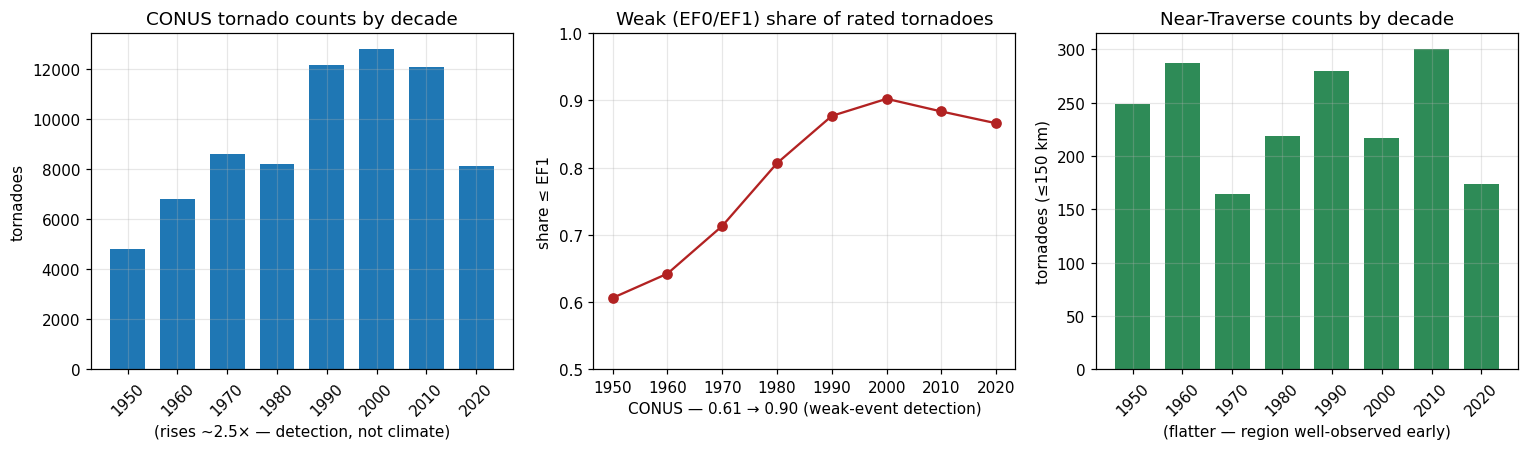

F→EF break (2007): the `mag` field carries F-scale ≤2006, EF ≥2007 in ONE column (no schema change):
  2006: n=1103  mag counts={0: 686, 1: 292, 2: 93, 3: 30, 4: 2}
  2007: n=1132  mag counts={-9: 21, 0: 682, 1: 301, 2: 92, 3: 31, 4: 4, 5: 1}
  2008: n=1704  mag counts={0: 983, 1: 506, 2: 156, 3: 49, 4: 9, 5: 1}

'-9' (UNKNOWN rating): 1,546 total, concentrated recent — by decade: {2000: 21, 2010: 299, 2020: 1226}
  → must be handled EXPLICITLY (never folded into EF0) in any severity distribution (M1).

TAKEAWAY (AWN-1): the EF0/EF1 record is dominated by improved DETECTION, not changing climate; the scale
changed in 2007; ~1.5k tornadoes are unrated; and wind reports are ~92% estimated, ~20% zero-magnitude,
left-censored at ~50 kt. A raw count is therefore NOT a hazard rate. M1 MUST bias-correct before fitting λ —
and must NOT silently restrict to 1996+ (the old repo did exactly that, with no correction).


In [7]:
tor["decade"] = (tor.yr // 10 * 10).astype("Int64")
tor["weak"] = tor.mag <= 1                          # EF0/EF1 — the detection-sensitive classes
conus = tor.groupby("decade").size()
weak_share = tor[tor.mag >= 0].groupby("decade")["weak"].mean()
T_tor = T["_tor"].copy(); T_tor["decade"] = (T_tor.yr // 10 * 10).astype("Int64")
near = T_tor.groupby("decade").size()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
axes[0].bar(conus.index.astype(int).astype(str), conus.values, width=0.7)
axes[0].set_title("CONUS tornado counts by decade"); axes[0].set_ylabel("tornadoes"); axes[0].tick_params(axis="x", rotation=45)
axes[0].set_xlabel("(rises ~2.5× — detection, not climate)")
axes[1].plot(weak_share.index.astype(int), weak_share.values, "o-", color="firebrick")
axes[1].set_title("Weak (EF0/EF1) share of rated tornadoes"); axes[1].set_ylabel("share ≤ EF1"); axes[1].set_ylim(0.5, 1.0)
axes[1].set_xlabel("CONUS — 0.61 → 0.90 (weak-event detection)")
axes[2].bar(near.index.astype(int).astype(str), near.values, width=0.7, color="seagreen")
axes[2].set_title("Near-Traverse counts by decade"); axes[2].set_ylabel("tornadoes (≤150 km)"); axes[2].tick_params(axis="x", rotation=45)
axes[2].set_xlabel("(flatter — region well-observed early)")
for ax in axes:
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

print("F→EF break (2007): the `mag` field carries F-scale ≤2006, EF ≥2007 in ONE column (no schema change):")
for y in (2006, 2007, 2008):
    vc = tor[tor.yr == y].mag.value_counts().sort_index()
    print(f"  {y}: n={int((tor.yr==y).sum()):4d}  mag counts={ {int(k):int(v) for k,v in vc.items()} }")
neg9 = tor[tor.mag == -9]
print(f"\n'-9' (UNKNOWN rating): {len(neg9):,} total, concentrated recent — by decade: "
      f"{ {int(k):int(v) for k,v in neg9.groupby('decade').size().items()} }")
print("  → must be handled EXPLICITLY (never folded into EF0) in any severity distribution (M1).")
print("\nTAKEAWAY (AWN-1): the EF0/EF1 record is dominated by improved DETECTION, not changing climate; the scale")
print("changed in 2007; ~1.5k tornadoes are unrated; and wind reports are ~92% estimated, ~20% zero-magnitude,")
print("left-censored at ~50 kt. A raw count is therefore NOT a hazard rate. M1 MUST bias-correct before fitting λ —")
print("and must NOT silently restrict to 1996+ (the old repo did exactly that, with no correction).")

## 8 · Episode de-duplication — one outbreak is *not* many events (Storm Events)

A tornado row is already one tornado (`sg==1`, §4). But a convective-wind **report** is one observation, and a
single storm system (**EPISODE**) spawns many — counting raw reports would inflate one outbreak many-fold.
Storm Events carries `EPISODE_ID`, so we can show the collapse. (The old repo's `process_noaa_data` collapsed
on episode — we reuse the *structure*, not its lack of bias-correction.)

In [8]:
se = pd.read_csv(fetch_stormevents(), compression="gzip", low_memory=False)
yr_se = int(se["YEAR"].iloc[0]) if "YEAR" in se.columns else int(re.search(r"_d(\d{4})_", fetch_stormevents().name).group(1))
wind_types = ["Thunderstorm Wind", "High Wind", "Strong Wind", "Tornado", "Marine Thunderstorm Wind"]
print(f"Storm Events — ONE recent complete year ({yr_se}; for episode-structure illustration, stated not silent):")
print(f"  {len(se):,} rows · {se['EPISODE_ID'].nunique():,} episodes · {se['EVENT_ID'].nunique():,} events")
print("  wind-relevant EVENT_TYPE counts:")
for et in wind_types:
    print(f"    {et:28s} {int((se.EVENT_TYPE==et).sum()):6d}")
ep = se.groupby("EPISODE_ID").size().sort_values(ascending=False)
big = ep.index[0]
print(f"\n  biggest EPISODE_ID {big} = {ep.iloc[0]} events (ONE storm system) → counting raw events inflates it {ep.iloc[0]}×.")
print(f"  collapse on EPISODE_ID ⇒ ~{se.groupby('EPISODE_ID').ngroups:,} independent systems, not {len(se):,} rows.")
if "MAGNITUDE_TYPE" in se.columns:
    print(f"\n  MAGNITUDE_TYPE (estimated vs measured): { se['MAGNITUDE_TYPE'].value_counts(dropna=False).to_dict() }")
    print("  → convective wind is overwhelmingly EG (estimated gust); tornadoes carry MAGNITUDE=NaN (severity = TOR_F_SCALE).")

Storm Events — ONE recent complete year (2025; for episode-structure illustration, stated not silent):
  72,360 rows · 9,846 episodes · 72,360 events
  wind-relevant EVENT_TYPE counts:
    Thunderstorm Wind             21807
    High Wind                      4603
    Strong Wind                    1116
    Tornado                        1591
    Marine Thunderstorm Wind       2126

  biggest EPISODE_ID 200143 = 412 events (ONE storm system) → counting raw events inflates it 412×.
  collapse on EPISODE_ID ⇒ ~9,846 independent systems, not 72,360 rows.

  MAGNITUDE_TYPE (estimated vs measured): {nan: 42619, 'EG': 18458, 'MG': 11116, 'MS': 145, 'ES': 22}
  → convective wind is overwhelmingly EG (estimated gust); tornadoes carry MAGNITUDE=NaN (severity = TOR_F_SCALE).


## 9 · Per-site tornado path statistics — the M2 path-aware Minkowski inputs (AWN-21)

Tornado coupling is **areal hit-or-miss**: the strike geometry is a *thin rectangle* `len × wid`. M2 needs, per
EF class, the path **length, width, and footprint area** — extracted here (raw, near each site). The naive
per-class rate is shown **only to flag it as un-bias-corrected** (§7); M1 produces the real λ.

In [9]:
def ef_label(m):
    return "unknown" if m < 0 else f"EF{int(m)}"

rows = []
window_yr = int(tor.yr.max() - tor.yr.min() + 1)
for a in ASSETS:
    t = a["_tor"]
    for m in sorted(t.mag.dropna().unique()):
        sub = t[t.mag == m]
        valid = sub[(sub.len > 0) & (sub.wid > 0)]
        area = (valid.len * MI_TO_KM) * (valid.wid * YD_TO_KM)        # km² (len_km × wid_km)
        rows.append({
            "site": a["slug"], "EF": ef_label(m), "n": len(sub),
            "len_mi_med": round(sub.len.median(), 2), "wid_yd_med": round(sub.wid.median(), 0),
            "area_km2_med": round(area.median(), 3) if len(area) else np.nan,
            "naive_lambda_per_yr": round(len(sub) / window_yr, 3),     # ⚠ UN-bias-corrected
        })
pathstats = pd.DataFrame(rows)
print(f"Per-site tornado path stats (collection radius {RADIUS_KM:.0f} km, window {window_yr} yr "
      f"[{int(tor.yr.min())}–{int(tor.yr.max())}]). naive_lambda is RAW — NOT bias-corrected (§7):\n")
print(pathstats.to_string(index=False))
print(f"\nEmpirical median path area vs old-repo EF-class constants (AWN-21, to reconcile at M2):")
print("  old-repo EF→km²:", OLD_REPO_EF_AREA_KM2, "— note the empirical len×wid medians are far smaller (median")
print("  paths are short/narrow); the old-repo areas likely encode a broader strike footprint. Flag for M2.")
print(f"\nlearning-06: the {RADIUS_KM:.0f} km radius is a homogeneity choice — its SIZE cancels in λ_asset =")
print("λ_collection · p_hit, so it must NOT be tuned to move the answer; pick it for uniform strike density only.")

Per-site tornado path stats (collection radius 150 km, window 76 yr [1950–2025]). naive_lambda is RAW — NOT bias-corrected (§7):

             site      EF   n  len_mi_med  wid_yd_med  area_km2_med  naive_lambda_per_yr
 traverse_wind_ok unknown  76        0.50        30.0         0.029                1.000
 traverse_wind_ok     EF0 823        0.20        25.0         0.009               10.829
 traverse_wind_ok     EF1 594        1.50        50.0         0.132                7.816
 traverse_wind_ok     EF2 282        3.75       100.0         0.524                3.711
 traverse_wind_ok     EF3  92        8.85       258.0         3.237                1.211
 traverse_wind_ok     EF4  20       21.42       880.0        27.745                0.263
 traverse_wind_ok     EF5   3       37.00      1760.0        77.862                0.039
shepherds_flat_or unknown   1        0.02        15.0         0.000                0.013
shepherds_flat_or     EF0  28        0.20        10.0         0.003  

## 10 · Distributions & coverage — the tornado tracks as a map

Plot each tornado as its **path** (start→end line; a point where the end is unknown), coloured by EF, inside the
150 km collection circle. The density contrast — Tornado-Alley Traverse vs Gorge Shepherds Flat — and the
path geometry (the basis of areal coupling) are both visible.

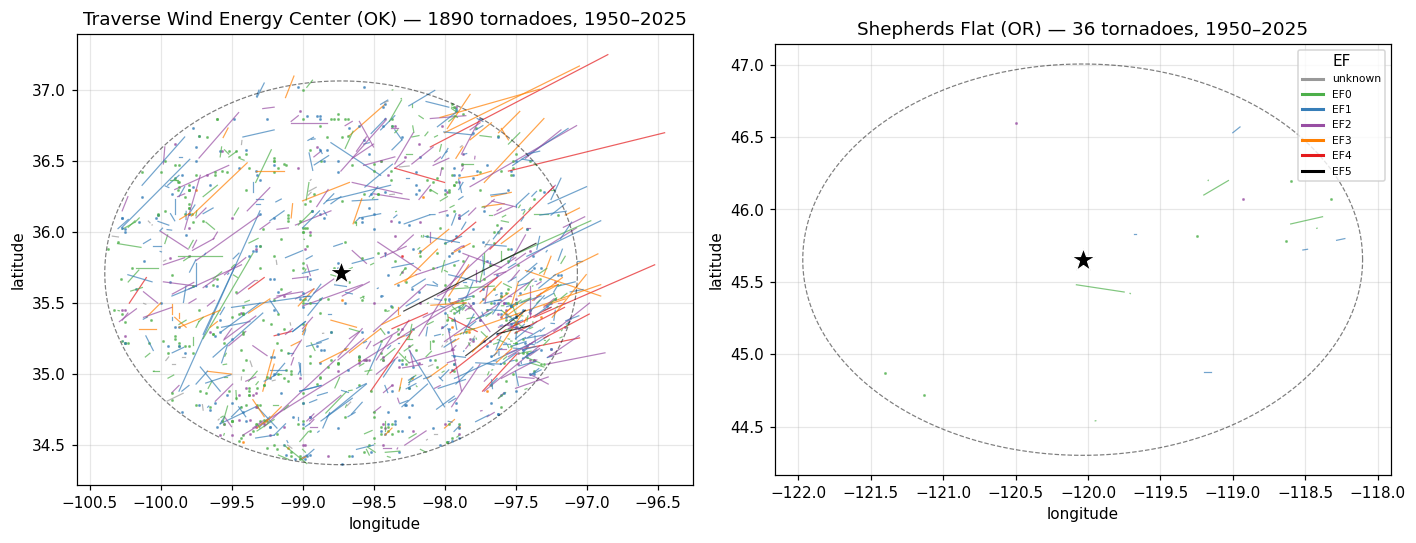

Takeaway: Traverse sits in a dense tornado field (1890 paths incl. EF3–EF5) — the catastrophic
single-asset tail; Shepherds Flat is nearly empty (36 paths, almost all weak) — the baseline.
Each LINE is the hit-or-miss footprint M2 intersects with the farm (path-aware Minkowski). Note: counts are
detection-biased (§7) — the MAP shows geometry & contrast, not a corrected frequency.


In [10]:
EF_COLORS = {"unknown": "0.6", "EF0": "#4daf4a", "EF1": "#377eb8", "EF2": "#984ea3",
             "EF3": "#ff7f00", "EF4": "#e41a1c", "EF5": "#000000"}
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, a in zip(axes, ASSETS):
    t = a["_tor"]
    for _, r in t.iterrows():
        c = EF_COLORS.get(ef_label(r.mag), "0.6")
        if r.elat and r.elon and not np.isnan(r.elat) and r.elat != 0:
            ax.plot([r.slon, r.elon], [r.slat, r.elat], "-", color=c, lw=0.8, alpha=0.7)
        else:
            ax.plot(r.slon, r.slat, ".", color=c, ms=2, alpha=0.6)
    th = np.linspace(0, 2 * np.pi, 200)
    ax.plot(a["lon"] + (RADIUS_KM / 111.0) * np.cos(th) / np.cos(np.radians(a["lat"])),
            a["lat"] + (RADIUS_KM / 111.0) * np.sin(th), "k--", lw=0.8, alpha=0.5)
    ax.plot(a["lon"], a["lat"], "k*", ms=16, mec="white", mew=0.8, zorder=5)
    ax.set_title(f"{a['name']} ({a['state']}) — {len(t)} tornadoes, 1950–{int(tor.yr.max())}")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.set_aspect("equal", "box"); ax.grid(alpha=0.3)
handles = [Line2D([0], [0], color=EF_COLORS[k], lw=2, label=k) for k in EF_COLORS]
axes[1].legend(handles=handles, fontsize=7, loc="upper right", title="EF")
plt.tight_layout(); plt.show()
print(f"Takeaway: Traverse sits in a dense tornado field ({len(T['_tor'])} paths incl. EF3–EF5) — the catastrophic")
print(f"single-asset tail; Shepherds Flat is nearly empty ({len(S['_tor'])} paths, almost all weak) — the baseline.")
print("Each LINE is the hit-or-miss footprint M2 intersects with the farm (path-aware Minkowski). Note: counts are")
print("detection-biased (§7) — the MAP shows geometry & contrast, not a corrected frequency.")

## 11 · Emit per-site records + manifests, and carry forward

In [11]:
for a in ASSETS:
    t = a["_tor"]
    rec = t[["yr", "mo", "dy", "mag", "slat", "slon", "elat", "elon", "len", "wid", "inj", "fat"]].copy()
    rec.insert(0, "sub_peril", "tornado")
    rec["ef"] = rec["mag"].map(ef_label)
    rec["path_area_km2"] = np.where((rec.len > 0) & (rec.wid > 0), rec.len * MI_TO_KM * rec.wid * YD_TO_KM, np.nan)
    out_pq = DATA_DIR / f"{a['slug']}_wind_m0_spc.parquet"
    rec.to_parquet(out_pq, index=False)

    w = a["_wnd"]
    manifest = {
        "layer": "M0", "source": "02_spc_storm_record", "peril": "wind",
        "asset": {k: a[k] for k in ("slug", "name", "role", "state", "lat", "lon", "capacity_mw")},
        "products": {
            "tornado": "SPC WCM 1950-2025_actual_tornadoes.csv (path geometry + EF; public domain)",
            "wind": "SPC WCM 1955-2025_wind.csv (severe-wind reports, knots; public domain)",
            "storm_events": "NOAA Storm Events (NCEI) — episode structure + MAGNITUDE_TYPE (recent year)",
        },
        "collection_radius_km": RADIUS_KM,
        "window_years": {"tornado": [int(tor.yr.min()), int(tor.yr.max())], "wind": [int(wnd.yr.min()), int(wnd.yr.max())]},
        "near_site_counts": {"tornado": int(len(t)), "wind_reports": int(len(w))},
        "ef_distribution": {ef_label(m): int((t.mag == m).sum()) for m in sorted(t.mag.dropna().unique())},
        "units": {"tornado_mag": "EF/F class (-9=unknown)", "wind_mag": "knots", "len": "miles", "wid": "yards"},
        "BIAS_CORRECTION_TODO": {                       # 🔴 the load-bearing flag for M1 (AWN-1)
            "status": "NOT corrected here — M0 audits only",
            "issues": ["weak-event detection rises ~0.61→0.90 share over decades",
                       "F→EF scale change in 2007", "-9 unknown ratings concentrated post-2010 (handle explicitly)",
                       "wind reports ~20% zero-magnitude, ~92% estimated, left-censored at ~50 kt (58 mph)"],
            "rule": "bias-correct BEFORE fitting λ; do NOT silently filter to 1996+ (old-repo omission)",
        },
        "ignored_fields": ["loss", "closs", "DAMAGE_PROPERTY (non-PV $ basis — the hail hail_hlrb/TIV lesson)"],
        "stationarity_note": "v1 stationary λ; flag eastward 'Dixie Alley' drift, do not freeze (AWN-19)",
    }
    (DATA_DIR / f"{a['slug']}_wind_m0_spc_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
    print(f"wrote {out_pq.relative_to(ROOT)} ({len(rec)} tornadoes) + manifest  "
          f"[wind reports near site: {len(w)}]")

wrote data/convective_wind/traverse_wind_ok_wind_m0_spc.parquet (1890 tornadoes) + manifest  [wind reports near site: 8638]
wrote data/convective_wind/shepherds_flat_or_wind_m0_spc.parquet (36 tornadoes) + manifest  [wind reports near site: 337]


### Findings & open questions (→ M1)

**What the record says.**
- **Tornado** is the catastrophic single-asset tail and lives *here* (no design surface covers its violent tail).
  Traverse: **~1,890 tornadoes** incl. EF3–EF5 in 150 km; Shepherds Flat: **~36** (almost all weak) — a ~50×
  proving-vs-baseline contrast, as expected.
- **The record is population/reporting-biased** (§7): weak-event detection rose 0.61→0.90 across decades, the
  scale changed in 2007, ~1.5k tornadoes are unrated, and wind reports are ~92% estimated / ~20% zero-magnitude /
  left-censored at ~50 kt. **A raw count is not a hazard rate.**
- **Path geometry** (len × wid × EF) is extracted per site for the M2 areal Minkowski (§9); the empirical path
  areas are far smaller than the old-repo EF-class constants — a reconciliation flagged for M2.

**Open → next phases.**
- **(M1, 🔴 the headline)** **bias-correct** the SPC frequency before fitting tornado λ + the bounded-GPD/EF
  severity — do **not** filter to 1996+ silently. Handle `-9` unknowns explicitly.
- **(M1)** strong-wind frequency: the **ASCE surface (01) is the design spine**; this SPC wind record is the
  bias-aware **cross-check** (knots → mph; mind the 50-kt censoring and estimated/measured split).
- **(M2)** reconcile the empirical len×wid path areas with the old-repo EF-class areas; per-turbine point-cloud
  vs areal footprint (USWTDB — notebook 03).
- **(M0)** **03_asset_geometry** next: the two sites' boundary polygon + USWTDB turbine points (the exposure the
  tornado paths above will intersect).

**Method-neutral.** This notebook *audits the evidence*; it fits no λ and computes no loss. Its deliverable is
the **bias caveat** that governs M1 — getting the frequency honest is the basics-spot-on fight for tornado.